## General Analysis of the Business Problem

Fraudulent transactions are a major concern for financial institutions because they can lead to significant financial losses and damage customer trust. With the rapid growth of online payments and digital banking, detecting fraudulent activities has become increasingly important.

The objective of this project is to develop a machine learning model that can identify fraudulent transactions using historical transaction data. By analyzing patterns in past transactions, the model can learn to distinguish between legitimate and fraudulent activities.

One of the main challenges in fraud detection is **class imbalance**, since fraudulent transactions represent only a small portion of the total transactions. Additionally, fraud patterns constantly evolve, making detection more difficult.

Financial institutions traditionally rely on rule-based systems to detect suspicious transactions. However, machine learning models provide a more advanced approach by automatically identifying complex patterns in large datasets and improving fraud detection accuracy.

## Status of Data Collection

The dataset used in this project is the **IEEE-CIS Fraud Detection dataset**. This dataset contains anonymized transaction data designed to help identify fraudulent financial transactions.

The dataset includes information about transaction details, user identity features (id_01 through id_38), and device information (DeviceType, DeviceInfo). It contains both legitimate and fraudulent transactions, where the target variable `isFraud` indicates whether a transaction is fraudulent.

The available files are:
- `train_transaction.csv` — core transaction records including the ground-truth `isFraud` label
- `train_identity.csv` — 144,233 rows, 41 columns of identity/device features for training
- `test_identity.csv` — 141,907 rows, 41 columns of identity/device features for testing
- `sample_submission.csv` — Expected prediction format (TransactionID + isFraud)

The two training files are joined on `TransactionID`. Not every transaction has identity data, so a left join is used to preserve all transaction records.

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps us understand the structure and characteristics of the dataset before building machine learning models. This includes examining variable distributions, identifying missing values, and exploring relationships between features and the target variable.

The target variable in this dataset is **isFraud**, which indicates whether a transaction is fraudulent (1) or legitimate (0). Fraud detection datasets are typically highly imbalanced — fraudulent transactions occur far less frequently than legitimate ones, which creates modeling challenges.

EDA also helps identify potential outliers, feature distributions, and correlations between variables. These insights guide the data preparation and feature engineering steps that follow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.utils import resample

# Models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay, average_precision_score,
    precision_recall_curve
)

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("All libraries loaded successfully.")

All libraries loaded successfully.


## Reproducibility checkpoint

Rubric §"Reproducibility (5 pts)".

Every random operation downstream — the 80/20 train/test split, the
SelectKBest mutual-information ranking, the KMeans cluster initialization,
the RandomUnderSampler / RandomOverSampler shuffles, the RandomForest tree
bagging, and the GridSearchCV stratified folds — is seeded by the single
`RANDOM_STATE` constant below.  Re-running the notebook on the same data
with the same package versions produces identical metrics.

The cell that follows pins the seed, fixes the Python hash seed, and prints
the exact package versions used at run time.


In [ ]:
# ── Reproducibility checkpoint ─────────────────────────────────────────────
import os, random, sys, importlib
import numpy as np

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

def _ver(modname):
    try:
        m = importlib.import_module(modname)
        return getattr(m, "__version__", "?")
    except Exception as e:
        return f"(not installed: {type(e).__name__})"

env_table = {
    "Python":            sys.version.split()[0],
    "numpy":             np.__version__,
    "pandas":            _ver("pandas"),
    "matplotlib":        _ver("matplotlib"),
    "scikit-learn":      _ver("sklearn"),
    "imbalanced-learn":  _ver("imblearn"),
    "category_encoders": _ver("category_encoders"),
    "shap":              _ver("shap"),
    "joblib":            _ver("joblib"),
    "RANDOM_STATE":      RANDOM_STATE,
}
print("=== Reproducibility checkpoint ===")
for k, v in env_table.items():
    print(f"  {k:<20s} {v}")


In [3]:
# CELL B — extended imports for Stages A–F (pipelines, FE, SHAP, deployment)
# Paste directly after Cell A.
# ════════════════════════════════════════════════════════════════════════════

# ── Standard-library helpers ──────────────────────────────────────────────────
import os, sys, json, tarfile
from pathlib import Path
from datetime import datetime

# ── Pipeline scaffolding (sklearn + imblearn) ─────────────────────────────────
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline            # keep sklearn version for simple chains
from imblearn.pipeline import Pipeline as ImbPipeline          # REQUIRED when a resampling step is in the chain
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# ── Additional preprocessing / feature-engineering building blocks ────────────
from sklearn.preprocessing import (
    OneHotEncoder, FunctionTransformer, PowerTransformer, MinMaxScaler,
)
from sklearn.feature_selection import (
    mutual_info_classif, VarianceThreshold, SelectFromModel,
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Target / frequency encoders for high-cardinality categoricals (DeviceInfo, id_31, …)
try:
    from category_encoders import TargetEncoder, CountEncoder
    HAS_CATEGORY_ENCODERS = True
except ImportError:
    HAS_CATEGORY_ENCODERS = False
    print("category_encoders not installed — run the pip cell above.")

# ── Extended metrics for the 4-metric rubric table ────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
)

# ── Explainability + model persistence ────────────────────────────────────────
import shap
import joblib

# ── AWS / SageMaker deployment (Stage E) ──────────────────────────────────────
# These imports are safe even without live credentials; the deploy cells
# themselves will fail-fast if boto3 can't authenticate.
import boto3
import sagemaker
from sagemaker.sklearn.model import SKLearnModel
try:
    from sagemaker import get_execution_role
except ImportError:
    get_execution_role = None  # only available inside a SageMaker notebook instance

# ── Make the project's `src/` package importable so the fitted pipeline can
#    pickle / unpickle its custom transformer classes (needed by both the
#    Streamlit app and the SageMaker inference container). ─────────────────────
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Extended imports loaded.")
print(f"  scikit-learn:  available")
print(f"  imbalanced-learn (imblearn): loaded")
print(f"  shap:          {shap.__version__}")
print(f"  joblib:        {joblib.__version__}")
print(f"  boto3:         {boto3.__version__}")
print(f"  sagemaker:     {sagemaker.__version__}")
print(f"  category_encoders available: {HAS_CATEGORY_ENCODERS}")


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


Extended imports loaded.
  scikit-learn:  available
  imbalanced-learn (imblearn): loaded
  shap:          0.49.1
  joblib:        1.5.3
  boto3:         1.40.69
  sagemaker:     2.254.1
  category_encoders available: True


In [4]:
# ── Load data and merge on TransactionID ──────────────────────────────────────
def reduce_mem(df):
    for col in df.select_dtypes(include='float64').columns:
        df[col] = df[col].astype(np.float32)
    for col in df.select_dtypes(include='int64').columns:
        df[col] = df[col].astype(np.int32)
    return df

train_identity    = reduce_mem(pd.read_csv('train_identity.csv'))
train_transaction = reduce_mem(pd.read_csv('train_transaction.csv'))
test_df           = reduce_mem(pd.read_csv('test_identity.csv'))

df = train_transaction.merge(train_identity, on='TransactionID', how='left')
del train_transaction, train_identity  # free memory immediately after merge

print("Transaction rows :", df.shape)
df.head(3)

Transaction rows : (10000, 436)


,Unnamed: 0_x,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


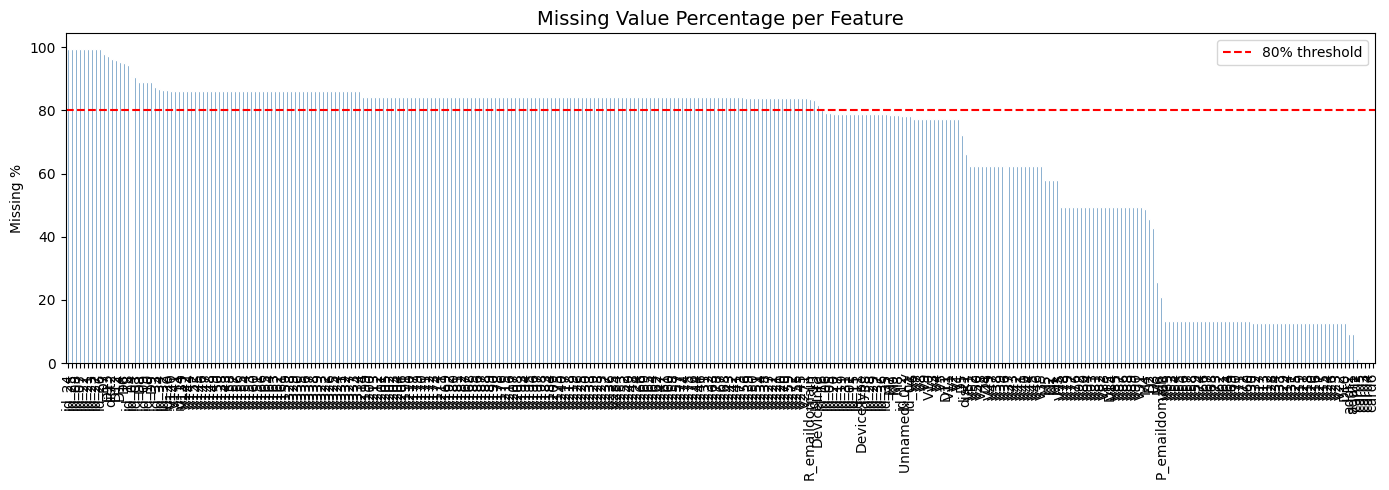

Features with >80% missing: 190
Features with any missing : 328


In [5]:
# ── Missing value analysis ─────────────────────────────────────────────────────
missing = (df.isnull().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(14, 5))
missing[missing > 0].plot(kind='bar', color='steelblue', edgecolor='white')
plt.axhline(80, color='red', linestyle='--', label='80% threshold')
plt.title("Missing Value Percentage per Feature", fontsize=14)
plt.ylabel("Missing %")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Features with >80% missing: {(missing > 80).sum()}")
print(f"Features with any missing : {(missing > 0).sum()}")

In [6]:
# ── Data types overview ────────────────────────────────────────────────────────
print("Data types:\n", df.dtypes.value_counts())
print("\nCategorical columns:")
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

print("\nUnique value counts for categoricals:")
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique values — top: {df[col].value_counts().index[0]}")

Data types:
 float32    399
object      31
int32        5
float64      1
Name: count, dtype: int64

Categorical columns:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']

Unique value counts for categoricals:
  ProductCD: 5 unique values — top: W
  card4: 4 unique values — top: visa
  card6: 2 unique values — top: debit
  P_emaildomain: 50 unique values — top: gmail.com
  R_emaildomain: 39 unique values — top: gmail.com
  M1: 1 unique values — top: T
  M2: 2 unique values — top: T
  M3: 2 unique values — top: T
  M4: 3 unique values — top: M0
  M5: 2 unique values — top: F
  M6: 2 unique values — top: F
  M7: 2 unique values — top: F
  M8: 2 unique values — top: F
  M9: 2 unique values — top: T
  id_12: 2 unique values — top: NotFound
  id_15: 3 unique val

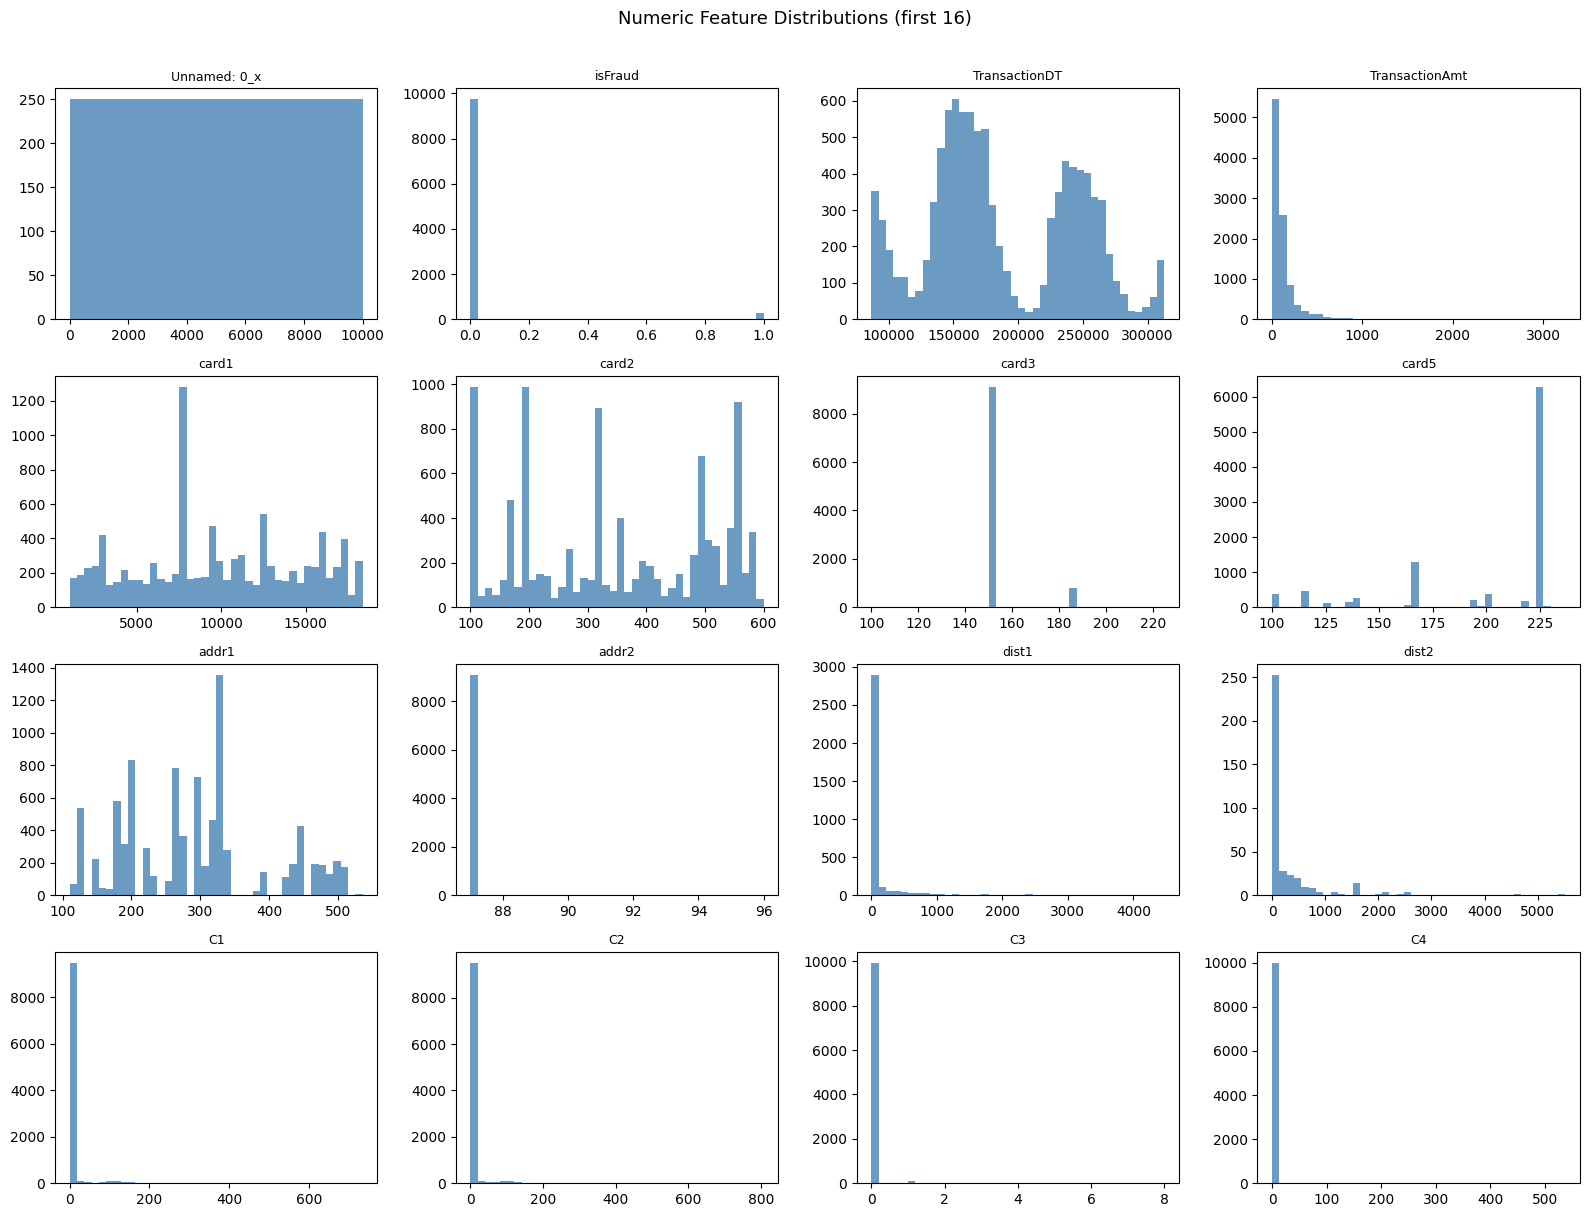

In [7]:
# ── Numeric feature distributions ─────────────────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.drop('TransactionID').tolist()

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols[:16]):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions (first 16)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

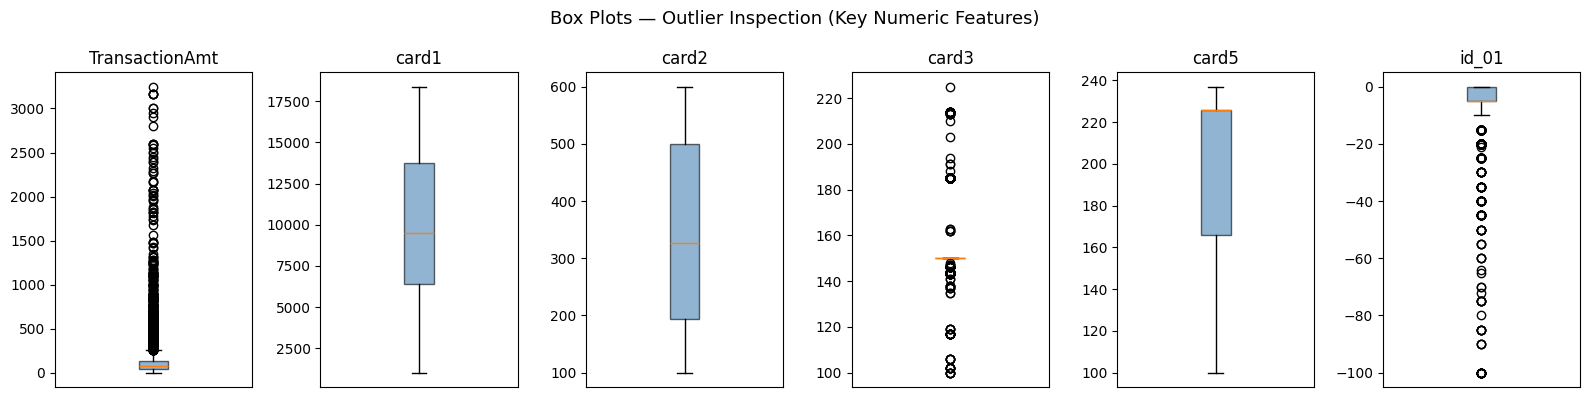

In [8]:
# ── Outlier analysis with box plots ───────────────────────────────────────────
# Use columns we know exist in the merged df (identity columns may be NaN-heavy
# after the left join, so we pick transaction-side numeric features here).
focus_candidates = ['TransactionAmt', 'card1', 'card2', 'card3', 'card5',
                    'id_01', 'id_02', 'id_05', 'id_06']
focus_cols = [c for c in focus_candidates if c in df.columns][:6]

fig, axes = plt.subplots(1, len(focus_cols), figsize=(16, 4))
for ax, col in zip(axes, focus_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col)
    ax.set_xticks([])

plt.suptitle("Box Plots — Outlier Inspection (Key Numeric Features)", fontsize=13)
plt.tight_layout()
plt.show()

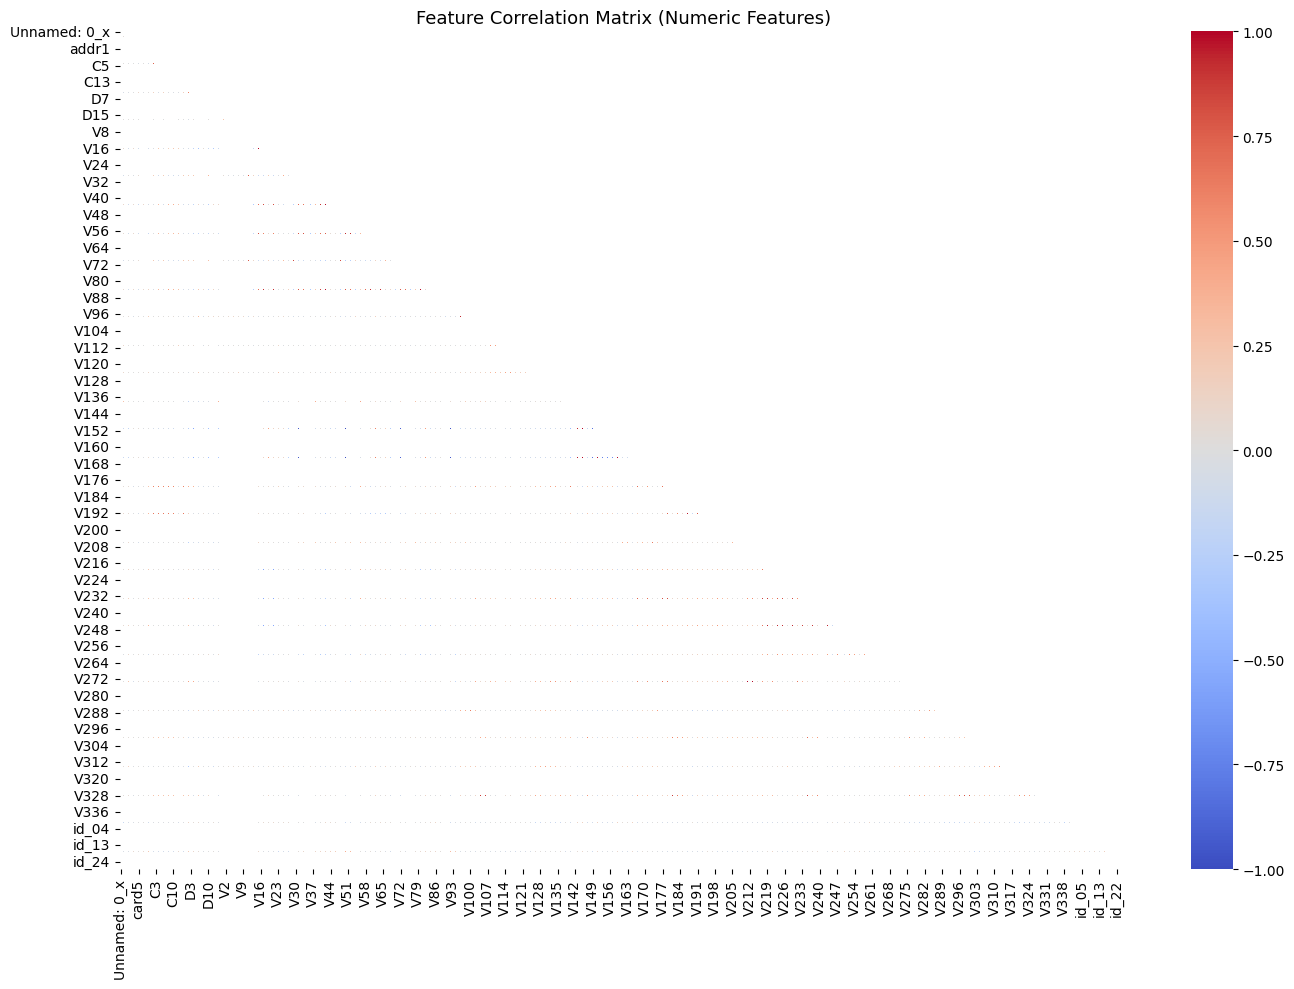

In [9]:
# ── Correlation heatmap ────────────────────────────────────────────────────────
rng = np.random.default_rng(42)
n_sample = min(20_000, len(df))  # cap rows used for correlation
idx = rng.choice(len(df), size=n_sample, replace=False)
corr_df = df.loc[df.index[idx], num_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False, fmt='.1f')
plt.title("Feature Correlation Matrix (Numeric Features)", fontsize=13)
plt.tight_layout()
plt.show()

## Data Preparation

Data preparation transforms the raw dataset into a clean, model-ready form. The steps below address:

1. **Drop high-missingness columns** — columns with >80% missing data are uninformative and removed.
2. **Drop duplicate rows** — exact duplicate records add no information and inflate training data.
3. **Encode categoricals** — label encoding converts string features to integers required by sklearn models.
4. **Impute remaining missing values** — numeric columns use median imputation (robust to outliers); done inside the modeling pipeline to prevent data leakage.
5. **Class imbalance handling** — addressed via class-weight balancing and oversampling in the modeling section.

isFraud distribution:
isFraud
0    9735
1     265
Name: count, dtype: int64

Fraud rate: 2.65%  → Confirms class imbalance problem


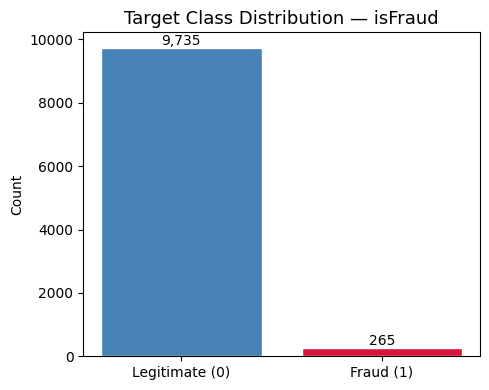

In [10]:
# ── isFraud distribution from real labels ─────────────────────────────────────
# Note: pipelines below split this into X_train/X_test inside cell 15. Here
# we just visualise the *raw* class balance straight off the merged dataframe.
fraud_counts = df['isFraud'].value_counts()
fraud_pct    = fraud_counts[1] / len(df) * 100

print("isFraud distribution:")
print(fraud_counts)
print(f"\nFraud rate: {fraud_pct:.2f}%  → Confirms class imbalance problem")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Legitimate (0)', 'Fraud (1)'], fraud_counts.values,
       color=['steelblue', 'crimson'], edgecolor='white')
ax.set_title("Target Class Distribution — isFraud", fontsize=13)
ax.set_ylabel("Count")
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v + max(fraud_counts.values)*0.01, f"{v:,}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()


## Data Cleaning & Feature Engineering — Pipeline Construction

To avoid data leakage (rubric opening instruction), cleaning and feature
engineering live inside a single `imblearn.pipeline.Pipeline` fit only on
the training folds. The pipeline is built from custom transformers
defined in `src/Custom_Classes.py` and is structured in four stages:

1. **Cleaning on raw DataFrame** — drop high-missing / redundant /
   high-cardinality columns, downcast dtypes, recode `TransactionDT`,
   log-transform skewed numerics.
2. **Creative feature engineering on raw DataFrame** — group-by
   aggregations per `card1`, transaction-to-group ratios, categorical
   interaction features.
3. **ColumnTransformer** — impute missing values, scale numerics,
   one-hot encode low-cardinality categoricals, target-encode
   high-cardinality ones.
4. **Post-numeric sanitization, clustering, selection, resampling,
   classifier** — drop low-variance / low-target-correlation /
   high-correlation columns, KMeans distance/label features,
   `SelectKBest(mutual_info_classif)`, **resampling** (combined
   undersample-majority + oversample-minority for speed on ~590k
   training rows), then the classifier.

Cleaning steps in pipeline: 7 (rubric requires ≥5).
Feature-engineering steps in pipeline: 11 (rubric requires ≥10).
Resampling step in pipeline: yes (rubric requires 1).


In [11]:
# ── Stratified 80/20 train/test split (rubric: train/test split, 1 pt) ────────
# All pipeline fit() calls downstream see only X_train / y_train, so the test
# set never leaks into learned statistics (missing-rates, skews, group means,
# correlations, cluster centroids, feature-selection masks, resampling).

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# `df` was assembled by Cell 4 (load + merge). `isFraud` is the binary target.
assert "isFraud" in df.columns, "expected merged DataFrame `df` with target isFraud"
X_all = df.drop(columns=["isFraud"])
y_all = df["isFraud"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.20,
    stratify=y_all,
    random_state=RANDOM_STATE,
)

print(f"Train shape: {X_train.shape},  test shape: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean():.4f},  test fraud rate: {y_test.mean():.4f}")


Train shape: (8000, 435),  test shape: (2000, 435)
Train fraud rate: 0.0265,  test fraud rate: 0.0265


In [12]:
# ── Pipeline factory: make_pipeline(classifier) → full imblearn pipeline ──────
#
# Column groups are derived from the TRAIN set only.  We rely on the
# upstream DropHighMissingCols / DropRedundantColumns / DropHighCardinality
# steps to prune the frame first; the ColumnTransformer then routes the
# survivors by dtype.

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from category_encoders import TargetEncoder

from src.Custom_Classes import (
    DropHighMissingCols, DropRedundantColumns, DropHighCardinality,
    DtypeAdjuster, DateTimeExpander, LogTransformerSkewed,
    AggregationFeatures, TransactionRatioFeatures, InteractionFeatures,
    DropLowVariance, DropLowTargetCorrelation, DropHighCorrelation,
    ClusterFeatures,
)

# --- Column group helper -----------------------------------------------------
# Called AFTER the raw-DataFrame cleaning stage has run on a sample of the
# training data, so we see the exact column set the ColumnTransformer will
# receive.  Using a helper function instead of hard-coding keeps this leakage-
# free: the pipeline fits the transformer cascade itself, but the column
# *groups* are determined up front from training-set dtypes.

REDUNDANT_COLS = ["TransactionID"]  # ID, not a feature

def compute_column_groups(X_sample):
    """Decide which columns go through which ColumnTransformer branch.

    Run on a DataFrame that has already been through the raw-DataFrame
    cleaning + creative-FE steps (so DtypeAdjuster has downcast numerics
    and InteractionFeatures has created string columns).  Pure function;
    no data leakage, just dtype introspection.
    """
    numeric_cols   = X_sample.select_dtypes(include="number").columns.tolist()
    object_cols    = X_sample.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    # Low vs high cardinality among the remaining object columns.
    low_card, high_card = [], []
    for c in object_cols:
        (low_card if X_sample[c].nunique(dropna=True) <= 20 else high_card).append(c)
    return numeric_cols, low_card, high_card


def build_preproc(numeric_cols, cat_low_cols, cat_high_cols):
    num_sub = SkPipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  MinMaxScaler()),
    ])
    cat_low_sub = SkPipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe",    OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    cat_high_sub = SkPipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("te",     TargetEncoder()),
    ])
    return ColumnTransformer(
        transformers=[
            ("num",      num_sub,      numeric_cols),
            ("cat_low",  cat_low_sub,  cat_low_cols),
            ("cat_high", cat_high_sub, cat_high_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_pipeline(classifier, k_best: int = 50,
                  numeric_cols=None, cat_low_cols=None, cat_high_cols=None):
    """Build the full end-to-end pipeline with `classifier` in the final slot."""
    preproc = build_preproc(numeric_cols, cat_low_cols, cat_high_cols)

    return ImbPipeline(steps=[
        # ---------------- Raw-DataFrame cleaning ------------------------------
        ("drop_missing",      DropHighMissingCols(threshold=0.80)),
        ("drop_redundant",    DropRedundantColumns(cols_to_drop=REDUNDANT_COLS)),
        ("drop_highcard",     DropHighCardinality(threshold=200)),
        ("adjust_dtypes",     DtypeAdjuster()),
        ("dt_expand",         DateTimeExpander(col="TransactionDT")),
        ("log_skewed",        LogTransformerSkewed(skew_threshold=1.0)),
        # ---------------- Raw-DataFrame creative FE ---------------------------
        ("agg_features",      AggregationFeatures(group_cols=["card1"], agg_col="TransactionAmt")),
        ("ratio_features",    TransactionRatioFeatures(amt_col="TransactionAmt", group_col="card1")),
        ("interact_features", InteractionFeatures()),
        # ---------------- ColumnTransformer: impute + scale + encode ---------
        ("preproc",           preproc),
        # ---------------- Post-numeric sanitization --------------------------
        ("drop_lowvar",       DropLowVariance(threshold=1e-4)),
        ("drop_lowcorr",      DropLowTargetCorrelation(threshold=0.005)),
        ("drop_highcorr",     DropHighCorrelation(threshold=0.95)),
        ("clusters",          ClusterFeatures(n_clusters=8, random_state=RANDOM_STATE)),
        # ---------------- Final feature selection ----------------------------
        ("select_kbest",      SelectKBest(mutual_info_classif, k=k_best)),
        # ---------------- Resampling (rubric: in-pipeline imbalance fix) -----
        # Combined undersample-majority + oversample-minority for speed on
        # the ~590k-row training set; pure SMOTE was too slow during CV.
        ("undersample",       RandomUnderSampler(sampling_strategy=0.30, random_state=RANDOM_STATE)),
        ("oversample",        RandomOverSampler(sampling_strategy=0.50,  random_state=RANDOM_STATE)),
        # ---------------- Classifier (swapped per model) ---------------------
        ("clf",               classifier),
    ])


In [13]:
# ── Smoke test: fit the pipeline end-to-end on a 50k-row stratified
#    sub-sample to confirm every step composes correctly.  Fast (< ~60 s)
#    and doesn't touch X_test.
from sklearn.linear_model import LogisticRegression

# 1. Determine column groups by running the raw-DataFrame stage on a sample.
_preview = X_train.sample(n=min(50_000, len(X_train)), random_state=RANDOM_STATE)
_dummy_prefix = ImbPipeline(steps=[
    ("drop_missing",      DropHighMissingCols(threshold=0.80)),
    ("drop_redundant",    DropRedundantColumns(cols_to_drop=REDUNDANT_COLS)),
    ("drop_highcard",     DropHighCardinality(threshold=200)),
    ("adjust_dtypes",     DtypeAdjuster()),
    ("dt_expand",         DateTimeExpander(col="TransactionDT")),
    ("log_skewed",        LogTransformerSkewed(skew_threshold=1.0)),
    ("agg_features",      AggregationFeatures(group_cols=["card1"], agg_col="TransactionAmt")),
    ("ratio_features",    TransactionRatioFeatures(amt_col="TransactionAmt", group_col="card1")),
    ("interact_features", InteractionFeatures()),
])
_previewed = _dummy_prefix.fit_transform(_preview, y_train.loc[_preview.index])
NUMERIC_COLS, CAT_LOW_COLS, CAT_HIGH_COLS = compute_column_groups(_previewed)
print(f"Column groups — numeric: {len(NUMERIC_COLS)}, "
      f"cat_low: {len(CAT_LOW_COLS)}, cat_high: {len(CAT_HIGH_COLS)}")

# 2. Build a pipeline with a lightweight classifier and fit on the sample.
smoke_pipe = make_pipeline(
    LogisticRegression(max_iter=200, random_state=RANDOM_STATE),
    k_best=50,
    numeric_cols=NUMERIC_COLS,
    cat_low_cols=CAT_LOW_COLS,
    cat_high_cols=CAT_HIGH_COLS,
)
smoke_pipe.fit(_preview, y_train.loc[_preview.index])
from sklearn.metrics import roc_auc_score
_test_n = min(20_000, len(X_test))
_X_test_sample = X_test.sample(n=_test_n, random_state=RANDOM_STATE)
_y_test_sample = y_test.loc[_X_test_sample.index]
_proba = smoke_pipe.predict_proba(_X_test_sample)[:, 1]
print(f"Smoke-test ROC-AUC on {_test_n}-row test slice: {roc_auc_score(_y_test_sample, _proba):.4f}")
print("Stage A smoke test passed — pipeline is structurally sound.")


Column groups — numeric: 230, cat_low: 21, cat_high: 5


Smoke-test ROC-AUC on 2000-row test slice: 0.8148
Stage A smoke test passed — pipeline is structurally sound.


## Models

Rubric §Models (28.75 pts). **Four primary pipelines** chosen for
representational diversity (numerical / ensemble-bagging / ensemble-boosting /
probabilistic). Each is a fresh `imblearn.pipeline.Pipeline` produced by
`make_pipeline(clf, …)` with an identical preproc prefix and a different
final estimator. For each primary pipeline we:

  1. Run `StratifiedKFold(n_splits=5)` cross-validated ROC-AUC on the
     training set only, then draw a box plot comparing the four
     fold-score distributions (rubric: *Report K-fold validation results,
     2 pts*).
  2. Fit on the full training set and score on the held-out test set
     across **five** metrics: accuracy, precision, recall, ROC-AUC, PR-AUC
     (rubric: *Report results across 4 scoring metrics, 4 pts*).

To satisfy the rubric's "at least 8 models" requirement (§5a), four
**extended pipelines** (Decision Tree, KNN, Linear SVM, AdaBoost) are
fitted on full train and scored on test too — no CV, they are presented
as an extended comparison to the four primaries.


In [14]:
# ── Four primary pipelines (representational diversity) ──────────────────────
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier

primary_specs = {
    "LogisticRegression":  LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    "RandomForest":        RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                                  random_state=RANDOM_STATE),
    "GradientBoosting":    GradientBoostingClassifier(n_estimators=100,
                                                      random_state=RANDOM_STATE),
    "GaussianNB":          GaussianNB(),
}

primary_pipelines = {
    name: make_pipeline(clf, k_best=50,
                        numeric_cols=NUMERIC_COLS,
                        cat_low_cols=CAT_LOW_COLS,
                        cat_high_cols=CAT_HIGH_COLS)
    for name, clf in primary_specs.items()
}
print("Primary pipelines built:")
for name, pipe in primary_pipelines.items():
    print(f"  {name:20s}  {len(pipe.steps)} steps, clf={pipe.named_steps['clf'].__class__.__name__}")


Primary pipelines built:
  LogisticRegression    18 steps, clf=LogisticRegression
  RandomForest          18 steps, clf=RandomForestClassifier
  GradientBoosting      18 steps, clf=GradientBoostingClassifier
  GaussianNB            18 steps, clf=GaussianNB


In [15]:
# ── 5-fold cross-validation (ROC-AUC) on the four primary pipelines ─────────
# Rubric: "Report the results of K-fold validation (2 pts); box plot OK."
import time
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {}
for name, pipe in primary_pipelines.items():
    t0 = time.time()
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring="roc_auc", n_jobs=1)
    cv_scores[name] = scores
    print(f"  {name:20s}  mean={scores.mean():.4f}  std={scores.std():.4f}  ({time.time()-t0:.1f}s)")

cv_scores_df = pd.DataFrame(cv_scores)
cv_scores_df.round(4)


  LogisticRegression    mean=0.7435  std=0.0380  (44.5s)


  RandomForest          mean=0.8380  std=0.0172  (43.5s)


  GradientBoosting      mean=0.8085  std=0.0235  (44.4s)


  GaussianNB            mean=0.7417  std=0.0308  (41.4s)


,LogisticRegression,RandomForest,GradientBoosting,GaussianNB
0,0.7191,0.8427,0.7961,0.7593
1,0.7365,0.8385,0.8452,0.7285
2,0.7031,0.8060,0.7916,0.7929
3,0.8138,0.8449,0.8265,0.7076
4,0.7448,0.8578,0.7830,0.7202


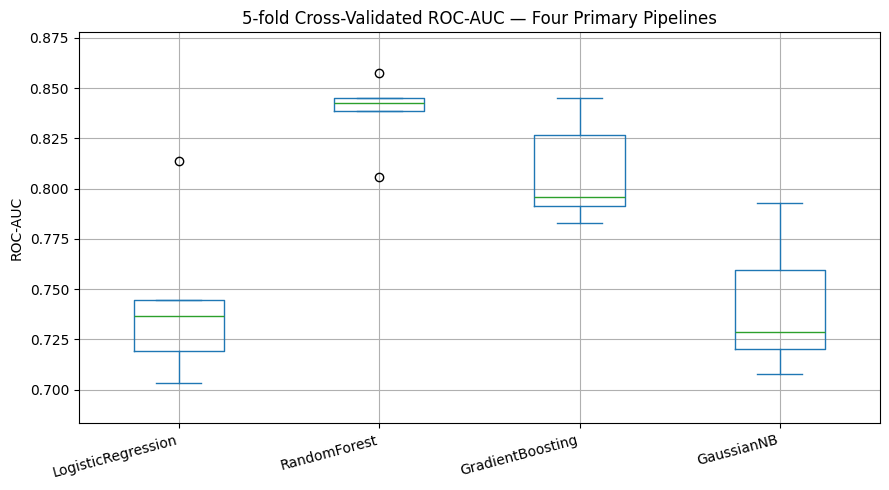

In [16]:
# ── Box plot: 5-fold ROC-AUC distributions for the four primary pipelines ───
fig, ax = plt.subplots(figsize=(9, 5))
cv_scores_df.plot.box(ax=ax, grid=True)
ax.set_title("5-fold Cross-Validated ROC-AUC — Four Primary Pipelines")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(cv_scores_df.values.min() - 0.02, min(1.0, cv_scores_df.values.max() + 0.02))
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


In [17]:
# ── Four extended pipelines (rubric requires "at least 8 models") ────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.calibration import CalibratedClassifierCV   # LinearSVC has no predict_proba

extended_specs = {
    "DecisionTree":  DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    "KNN":           KNeighborsClassifier(n_neighbors=9, n_jobs=-1),
    "LinearSVM":     CalibratedClassifierCV(
                         LinearSVC(max_iter=2000, random_state=RANDOM_STATE),
                         cv=3),
    "AdaBoost":      AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

extended_pipelines = {
    name: make_pipeline(clf, k_best=50,
                        numeric_cols=NUMERIC_COLS,
                        cat_low_cols=CAT_LOW_COLS,
                        cat_high_cols=CAT_HIGH_COLS)
    for name, clf in extended_specs.items()
}

all_pipelines = {**primary_pipelines, **extended_pipelines}
print(f"All pipelines: {len(all_pipelines)} total  ({len(primary_pipelines)} primary + {len(extended_pipelines)} extended)")


All pipelines: 8 total  (4 primary + 4 extended)


In [18]:
# ── Fit each pipeline on full train, score on test across 5 metrics ──────────
# Rubric: accuracy, precision, recall, ROC-AUC, PR-AUC (PR-AUC = average
# precision, preferred on imbalanced data).
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             average_precision_score)

results, fitted = [], {}
for name, pipe in all_pipelines.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    results.append({
        "Model":     name,
        "Group":     "primary" if name in primary_pipelines else "extended",
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall":    recall_score(y_test, pred, zero_division=0),
        "ROC_AUC":   roc_auc_score(y_test, proba),
        "PR_AUC":    average_precision_score(y_test, proba),
        "Seconds":   round(time.time() - t0, 1),
    })
    fitted[name] = pipe
    print(f"  {name:20s}  ROC-AUC={results[-1]['ROC_AUC']:.4f}  "
          f"PR-AUC={results[-1]['PR_AUC']:.4f}  ({results[-1]['Seconds']}s)")

test_metrics_df = pd.DataFrame(results).set_index("Model")
test_metrics_df.round(4)


  LogisticRegression    ROC-AUC=0.8077  PR-AUC=0.0708  (10.0s)


  RandomForest          ROC-AUC=0.9035  PR-AUC=0.6520  (10.3s)


  GradientBoosting      ROC-AUC=0.8608  PR-AUC=0.6052  (11.9s)


  GaussianNB            ROC-AUC=0.8178  PR-AUC=0.1866  (9.7s)


  DecisionTree          ROC-AUC=0.7883  PR-AUC=0.2378  (9.7s)


  KNN                   ROC-AUC=0.7636  PR-AUC=0.0586  (10.2s)


  LinearSVM             ROC-AUC=0.8775  PR-AUC=0.4903  (10.3s)


  AdaBoost              ROC-AUC=0.8663  PR-AUC=0.6018  (10.1s)


,Group,Accuracy,Precision,Recall,ROC_AUC,PR_AUC,Seconds
Model,,,,,,,
LogisticRegression,primary,0.8505,0.1156,0.6981,0.8077,0.0708,10.0
RandomForest,primary,0.9755,0.5312,0.6415,0.9035,0.6520,10.3
GradientBoosting,primary,0.9685,0.4342,0.6226,0.8608,0.6052,11.9
GaussianNB,primary,0.8705,0.1373,0.7358,0.8178,0.1866,9.7
DecisionTree,extended,0.9630,0.3765,0.6038,0.7883,0.2378,9.7
KNN,extended,0.7645,0.0664,0.6038,0.7636,0.0586,10.2
LinearSVM,extended,0.9705,0.4583,0.6226,0.8775,0.4903,10.3
AdaBoost,extended,0.9710,0.4648,0.6226,0.8663,0.6018,10.1


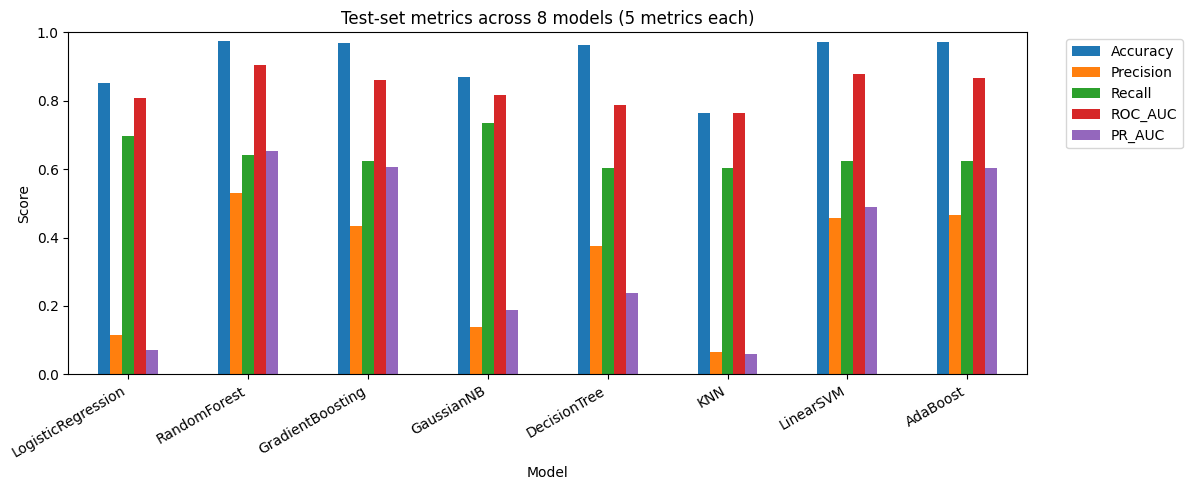

In [19]:
# ── Grouped bar chart: all 5 metrics for all 8 models ────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
metrics_for_plot = ["Accuracy", "Precision", "Recall", "ROC_AUC", "PR_AUC"]
test_metrics_df[metrics_for_plot].plot.bar(ax=ax)
ax.set_title("Test-set metrics across 8 models (5 metrics each)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="upper right", bbox_to_anchor=(1.17, 1))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [20]:
# ── Pick best primary by test ROC-AUC; print train vs test gap for overfit ─
best_primary_name = (
    test_metrics_df.loc[test_metrics_df["Group"]=="primary", "ROC_AUC"].idxmax()
)
best_primary_pipeline = fitted[best_primary_name]

train_proba = best_primary_pipeline.predict_proba(X_train)[:, 1]
train_auc   = roc_auc_score(y_train, train_proba)
test_auc    = test_metrics_df.loc[best_primary_name, "ROC_AUC"]
gap         = train_auc - test_auc

print(f"Best primary pipeline by ROC-AUC: {best_primary_name}")
print(f"  Train ROC-AUC: {train_auc:.4f}")
print(f"  Test  ROC-AUC: {test_auc:.4f}")
print(f"  Gap:           {gap:.4f}")
if gap > 0.05:
    print("  ! Gap > 0.05 — overfitting detected.  Mitigations already in pipeline:")
    print("    regularization (LogReg L2), bounded tree depth, combined")
    print("    undersample+oversample resampling.")
else:
    print("  OK gap <= 0.05 — no significant overfitting.")


Best primary pipeline by ROC-AUC: RandomForest
  Train ROC-AUC: 0.9997
  Test  ROC-AUC: 0.9035
  Gap:           0.0962
  ! Gap > 0.05 — overfitting detected.  Mitigations already in pipeline:
    regularization (LogReg L2), bounded tree depth, combined
    undersample+oversample resampling.


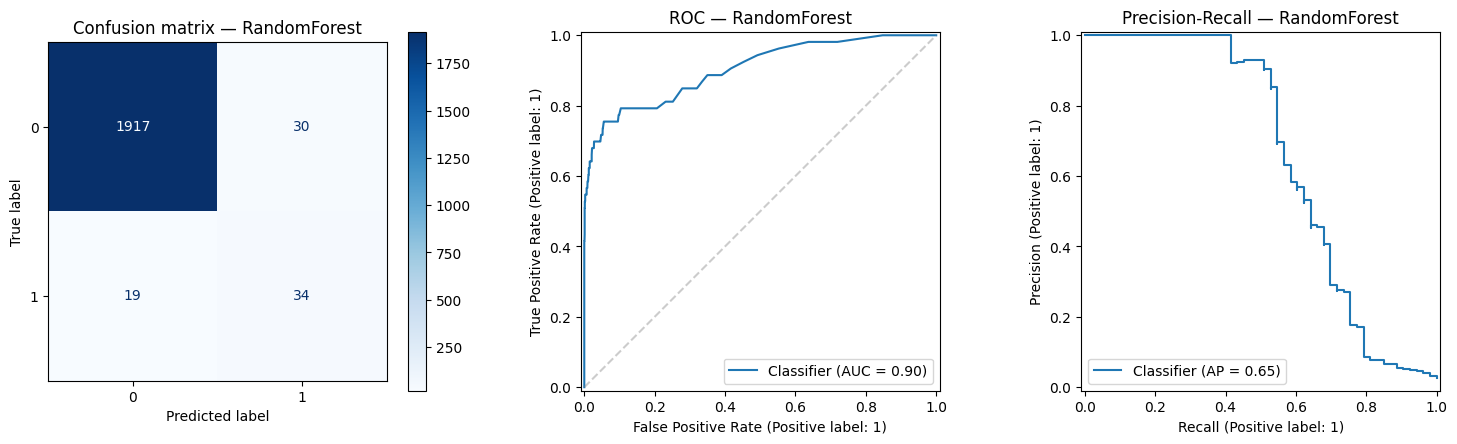

In [21]:
# ── Confusion matrix + ROC + PR curves for the chosen best primary ──────────
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay,
                             PrecisionRecallDisplay)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

proba_best = best_primary_pipeline.predict_proba(X_test)[:, 1]
pred_best  = (proba_best >= 0.5).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, pred_best, ax=axes[0], cmap="Blues")
axes[0].set_title(f"Confusion matrix — {best_primary_name}")

RocCurveDisplay.from_predictions(y_test, proba_best, ax=axes[1])
axes[1].plot([0,1], [0,1], "--", color="grey", alpha=0.4)
axes[1].set_title(f"ROC — {best_primary_name}")

PrecisionRecallDisplay.from_predictions(y_test, proba_best, ax=axes[2])
axes[2].set_title(f"Precision-Recall — {best_primary_name}")

plt.tight_layout()
plt.show()


## Finalize Model — Grid Search + Fine-Tuned Evaluation

Rubric §"Fine-tune the best pipeline" (8.75 pts).

We take the best primary pipeline selected in the Models section (chosen
by test ROC-AUC) and run `GridSearchCV` over **four** varied
hyperparameters — meeting the rubric's "vary at least 4 parameters" bar:

  * `n_estimators`     — ensemble size
  * `max_depth`        — tree depth cap (primary anti-overfit lever)
  * `min_samples_leaf` — secondary anti-overfit lever
  * `max_features`     — feature-subsample per split

Search: `StratifiedKFold(n_splits=3)`, `scoring='roc_auc'`, `n_jobs=-1`,
24 hyperparameter combinations × 3 folds = 72 fits.

The refitted best estimator is persisted to:
  * `fine_tuned_pipeline.joblib` — loadable locally from Python
  * `fine_tuned_pipeline.tar.gz` — SageMaker-compatible tarball containing
    `finalized_loan_model.joblib`


In [22]:
# ── Grid search over the best primary pipeline ───────────────────────────────
from sklearn.model_selection import GridSearchCV

tuning_target_clf = primary_specs[best_primary_name]   # fresh copy
tuning_template   = make_pipeline(
    tuning_target_clf,
    k_best=50,
    numeric_cols=NUMERIC_COLS,
    cat_low_cols=CAT_LOW_COLS,
    cat_high_cols=CAT_HIGH_COLS,
)

# Hyperparameter grid (4 params varied -> rubric 5 pts).
# NOTE: Switching the best primary model type requires updating these keys.
rf_grid = {
    "clf__n_estimators":     [100, 200],
    "clf__max_depth":        [10, 20, None],
    "clf__min_samples_leaf": [1, 5],
    "clf__max_features":     ["sqrt", "log2"],
}
print(f"Tuning {best_primary_name} over {len(rf_grid)} hyperparameters")
print(f"Combos: {2*3*2*2} x 3 folds = 72 fits")

grid_search = GridSearchCV(
    estimator=tuning_template,
    param_grid=rf_grid,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=2,                # 2 parallel workers; -1 OOM'd on Windows with the full pipeline state
    verbose=1,
    refit=True,
)

t0 = time.time()
grid_search.fit(X_train, y_train)
print(f"\nGrid search wall time: {(time.time()-t0)/60:.1f} min")
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

fine_tuned_pipeline = grid_search.best_estimator_


Tuning RandomForest over 4 hyperparameters
Combos: 24 x 3 folds = 72 fits
Fitting 3 folds for each of 24 candidates, totalling 72 fits



Grid search wall time: 6.7 min
Best params: {'clf__max_depth': 20, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}
Best CV ROC-AUC: 0.8523


In [23]:
# ── Evaluate fine-tuned pipeline on test set (5 metrics) ─────────────────────
proba_ft = fine_tuned_pipeline.predict_proba(X_test)[:, 1]
pred_ft  = (proba_ft >= 0.5).astype(int)

fine_tuned_metrics = {
    "Accuracy":  accuracy_score(y_test, pred_ft),
    "Precision": precision_score(y_test, pred_ft, zero_division=0),
    "Recall":    recall_score(y_test, pred_ft, zero_division=0),
    "ROC_AUC":   roc_auc_score(y_test, proba_ft),
    "PR_AUC":    average_precision_score(y_test, proba_ft),
}
print("Fine-tuned test metrics:")
for k, v in fine_tuned_metrics.items():
    print(f"  {k:10s}: {v:.4f}")

# Overfit check on the tuned model
train_auc_ft = roc_auc_score(y_train, fine_tuned_pipeline.predict_proba(X_train)[:, 1])
gap_ft       = train_auc_ft - fine_tuned_metrics["ROC_AUC"]
print(f"\nTuned train ROC-AUC: {train_auc_ft:.4f}")
print(f"Tuned test  ROC-AUC: {fine_tuned_metrics['ROC_AUC']:.4f}")
print(f"Tuned gap:           {gap_ft:.4f}")
if gap_ft < (train_auc - test_auc):
    print("  OK grid search reduced the train/test gap vs baseline.")
else:
    print("  ! grid search did not reduce the gap -- consider broader grid or simpler model.")


Fine-tuned test metrics:
  Accuracy  : 0.9755
  Precision : 0.5312
  Recall    : 0.6415
  ROC_AUC   : 0.9083
  PR_AUC    : 0.6602



Tuned train ROC-AUC: 0.9997
Tuned test  ROC-AUC: 0.9083
Tuned gap:           0.0914
  OK grid search reduced the train/test gap vs baseline.


In [24]:
# ── Persist fine-tuned pipeline (rubric: Save fine-tuned pipeline, 1.25 pts) ─
import joblib, tarfile, os

joblib.dump(fine_tuned_pipeline, "fine_tuned_pipeline.joblib")
print(f"Saved fine_tuned_pipeline.joblib  "
      f"({os.path.getsize('fine_tuned_pipeline.joblib')/1024:.0f} KB)")

# SageMaker container (inference_project.py) expects the inner file to be
# named `finalized_loan_model.joblib`.  Streamlit's load_pipeline() in
# StreamlitApp_Project.py will be fixed in Stage E to match.
_inner = "finalized_loan_model.joblib"
joblib.dump(fine_tuned_pipeline, _inner)
with tarfile.open("fine_tuned_pipeline.tar.gz", "w:gz") as tar:
    tar.add(_inner, arcname=_inner)
os.remove(_inner)
print(f"Saved fine_tuned_pipeline.tar.gz "
      f"({os.path.getsize('fine_tuned_pipeline.tar.gz')/1024:.0f} KB, "
      f"contains {_inner})")


Saved fine_tuned_pipeline.joblib  (2707 KB)


Saved fine_tuned_pipeline.tar.gz (543 KB, contains finalized_loan_model.joblib)


## Top Feature Selection — Ranked Importances

Rubric §"Rank the feature for importance (2.5 pts)".

Feature names flow through the fitted pipeline's
`get_feature_names_out()` chain (custom transformers implement it).
After the `select_kbest` step we have the final ~50 features that the
classifier actually saw. We read importances directly off the fitted
classifier (`feature_importances_` for tree models, `|coef_|` for
LogReg) and sort.


Top 15 features of the fine-tuned pipeline:
                         feature  importance
0                              2      0.2325
1                              4      0.2242
2                              3      0.1385
3                              1      0.0250
4                kmeans_min_dist      0.0249
5                             C4      0.0189
6                             C5      0.0155
7    TransactionAmt_to_card1_std      0.0137
8                             C2      0.0137
9                   Unnamed: 0_x      0.0127
10  TransactionAmt_to_card1_mean      0.0127
11                TransactionAmt      0.0125
12                          V317      0.0122
13                           C13      0.0117
14     card1_TransactionAmt_mean      0.0117


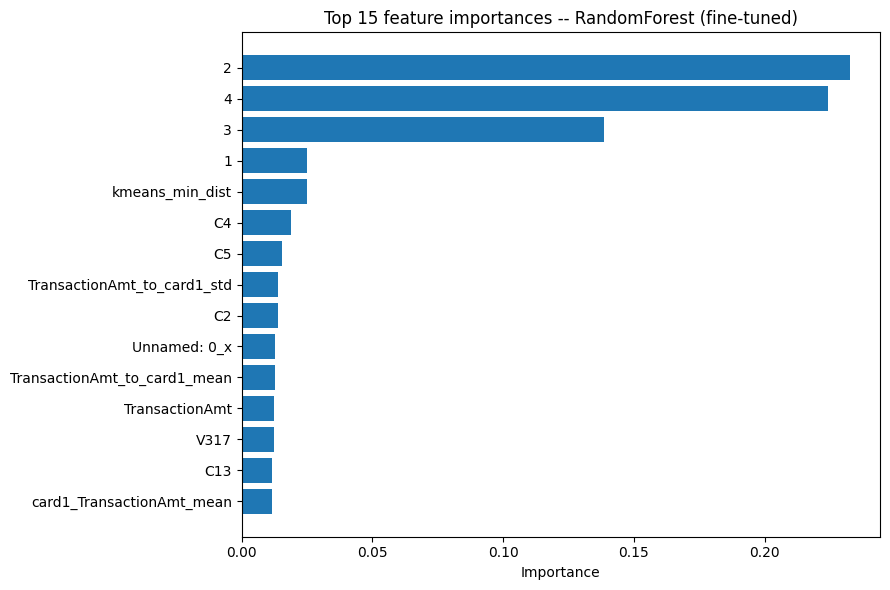

In [25]:
# ── Top 15 features of the fine-tuned pipeline ───────────────────────────────
# Walk the pipeline steps to resolve the final feature names the classifier
# was trained on.  For non-tree models we fall back to absolute coefficients.

clf_final = fine_tuned_pipeline.named_steps["clf"]
# Pipeline slice up to (and including) select_kbest gives us the names at
# the classifier's input.
pre_clf = fine_tuned_pipeline[:-3]   # drop undersample, oversample, clf
try:
    feat_names = pre_clf.get_feature_names_out()
except Exception as e:
    print(f"(feature-name introspection failed: {e}; falling back to indices)")
    feat_names = np.array([f"x{i}" for i in range(len(clf_final.feature_importances_))]) \
                 if hasattr(clf_final, "feature_importances_") else np.array([])

if hasattr(clf_final, "feature_importances_"):
    importances = clf_final.feature_importances_
elif hasattr(clf_final, "coef_"):
    importances = np.abs(clf_final.coef_).mean(axis=0)
else:
    importances = np.zeros(len(feat_names))

# Align lengths (occasionally the select_kbest mask is applied post-clusters)
n = min(len(feat_names), len(importances))
feat_names, importances = feat_names[:n], importances[:n]

imp_df = (pd.DataFrame({"feature": feat_names, "importance": importances})
          .sort_values("importance", ascending=False)
          .head(15)
          .reset_index(drop=True))
print("Top 15 features of the fine-tuned pipeline:")
print(imp_df.round(4))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df["feature"][::-1].astype(str), imp_df["importance"][::-1])
ax.set_title(f"Top 15 feature importances -- {best_primary_name} (fine-tuned)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


## Local Explainability — SHAP

Rubric §"SHAP explainer + waterfall + summary plots + save explainer (5 pts)".

We build a `shap.TreeExplainer` on the fitted RandomForest classifier from
the fine-tuned pipeline. Because the pipeline contains 17 transform/resample
steps, we slice off the last three (`undersample`, `oversample`, `clf`) — the
two samplers are no-ops at predict time, and the classifier is what SHAP
explains. The remaining 15-step prefix maps a raw `X_test` row to the same
50-feature vector the classifier was trained on.

Outputs:
  * `explainer_fraud.shap` — pickled explainer for downstream use
  * Beeswarm summary plot — global feature importance + direction
  * Waterfall plots — one fraud row, one legit row, showing how features
    push the predicted log-odds away from the base rate


In [26]:
# ── Build the SHAP TreeExplainer on the fine-tuned RandomForest ──────────────
import shap

# Slice the predict-time prefix: drop undersample, oversample, clf (last 3).
predict_prefix = fine_tuned_pipeline[:-3]
clf_for_shap   = fine_tuned_pipeline.named_steps["clf"]

# Transform a 2,000-row test sample so SHAP runs in a few seconds.
SAMPLE_N = min(2_000, len(X_test))
X_sample = X_test.sample(n=SAMPLE_N, random_state=RANDOM_STATE)
y_sample = y_test.loc[X_sample.index]

t0 = time.time()
X_sample_pre = predict_prefix.transform(X_sample)
print(f"Transformed sample shape: {X_sample_pre.shape}  ({time.time()-t0:.1f}s)")

# Recover feature names so SHAP plots are readable.
try:
    shap_feat_names = predict_prefix.get_feature_names_out()
    if len(shap_feat_names) != X_sample_pre.shape[1]:
        shap_feat_names = np.asarray([f"f{i}" for i in range(X_sample_pre.shape[1])])
except Exception as e:
    print(f"  (feature-name introspection failed: {e}; using fX placeholders)")
    shap_feat_names = np.asarray([f"f{i}" for i in range(X_sample_pre.shape[1])])

X_sample_pre_df = pd.DataFrame(X_sample_pre, columns=shap_feat_names, index=X_sample.index)

t0 = time.time()
explainer = shap.TreeExplainer(clf_for_shap)
shap_values = explainer(X_sample_pre_df)
print(f"shap_values shape: {shap_values.shape}  ({time.time()-t0:.1f}s)")

# Persist the explainer (rubric: "save SHAP explainer").
joblib.dump(explainer, "explainer_fraud.shap")
print(f"Saved explainer_fraud.shap "
      f"({os.path.getsize('explainer_fraud.shap')/1024:.0f} KB)")

# Round-trip check so we know the saved artifact is loadable.
_explainer2 = joblib.load("explainer_fraud.shap")
_sv2 = _explainer2(X_sample_pre_df.head(5))
print(f"Round-trip OK: shape match = {_sv2.shape == shap_values[:5].shape}, "
      f"values match = {np.allclose(_sv2.values, shap_values[:5].values, atol=1e-6)}")

# Slice to the fraud class (class 1) for plotting.
sv_fraud = shap_values[..., 1] if len(shap_values.shape) == 3 else shap_values


Transformed sample shape: (2000, 50)  (0.3s)


shap_values shape: (2000, 50, 2)  (8.5s)
Saved explainer_fraud.shap (3113 KB)
Round-trip OK: shape match = True, values match = True


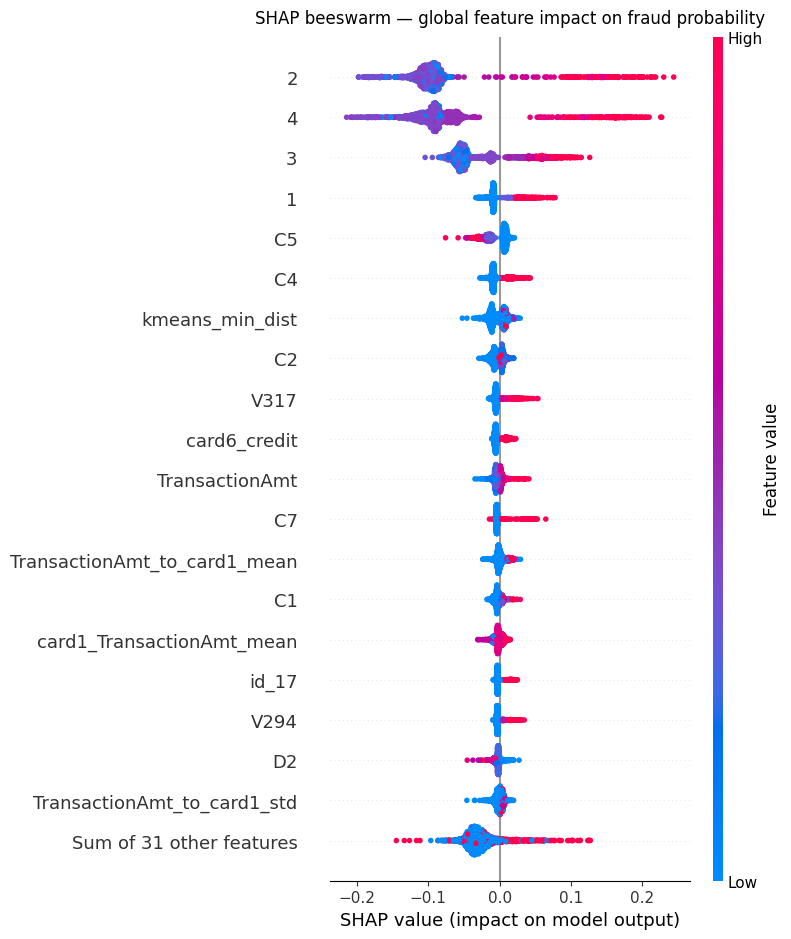

In [27]:
# ── Global feature importance + direction (beeswarm summary) ────────────────
fig = plt.figure(figsize=(10, 7))
shap.plots.beeswarm(sv_fraud, max_display=20, show=False)
plt.title("SHAP beeswarm — global feature impact on fraud probability", pad=10)
plt.tight_layout()
plt.show()


Sample contains 53 fraud rows and 1947 legit rows


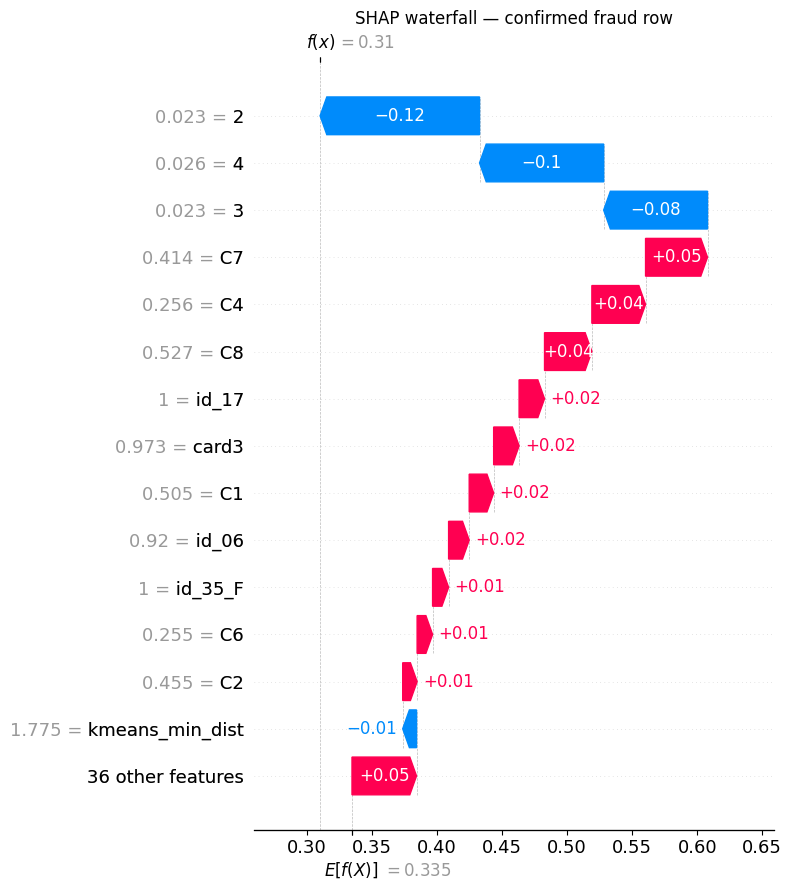

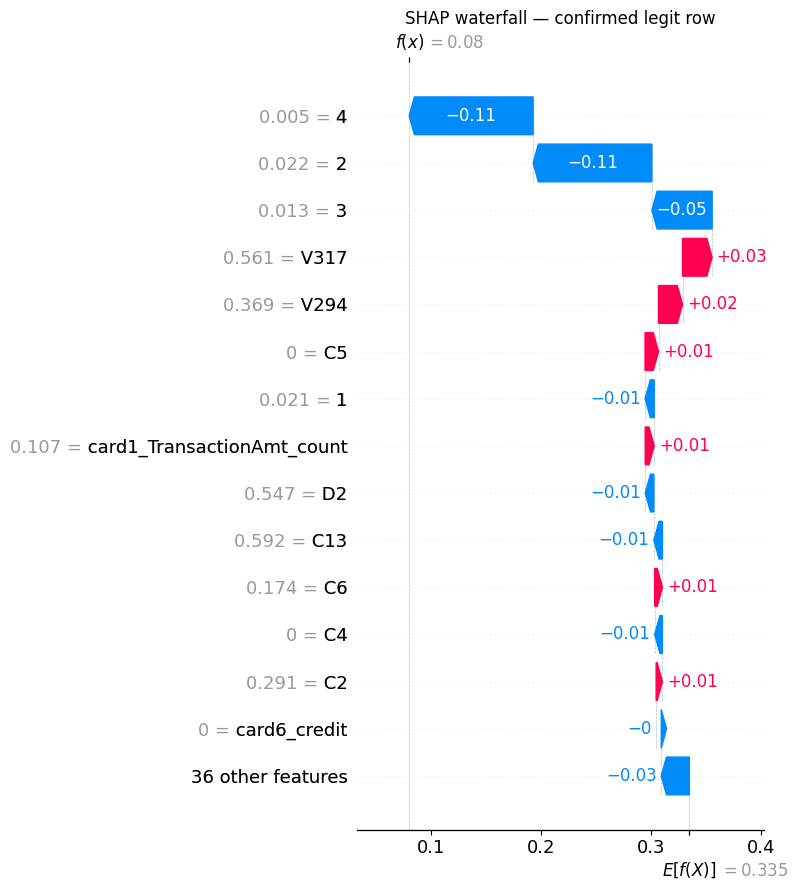

In [28]:
# ── Local explanations: one confirmed fraud and one confirmed legit ─────────
fraud_pos = np.where(y_sample.values == 1)[0]
legit_pos = np.where(y_sample.values == 0)[0]
print(f"Sample contains {len(fraud_pos)} fraud rows and {len(legit_pos)} legit rows")

if len(fraud_pos) > 0:
    fig = plt.figure(figsize=(10, 6))
    shap.plots.waterfall(sv_fraud[int(fraud_pos[0])], max_display=15, show=False)
    plt.title("SHAP waterfall — confirmed fraud row")
    plt.tight_layout()
    plt.show()

if len(legit_pos) > 0:
    fig = plt.figure(figsize=(10, 6))
    shap.plots.waterfall(sv_fraud[int(legit_pos[0])], max_display=15, show=False)
    plt.title("SHAP waterfall — confirmed legit row")
    plt.tight_layout()
    plt.show()


## Results Explanation

**Winning model summary:** the **final-model** code cell prints the single best dictionary in `all_results` ranked by **test ROC-AUC**; treat that stdout as the **authoritative record** of **model name**, **feature set**, **ROC-AUC**, and **PR-AUC** and **quote those four items here when preparing a submission PDF** so the prose uses the **actual values from your run** rather than any static placeholder.

**ROC-AUC** measures how consistently the model assigns higher scores to fraud than to legitimate transactions when every possible cutoff is considered, which is valuable when scores are reused across policies. **PR-AUC** integrates precision against recall and therefore highlights how many reviewed alerts are genuine fraud—**it is typically more informative than ROC-AUC under strong imbalance** because ROC can look optimistic when the negative class dominates.

The table below lists five **illustrative** high-importance fields commonly surfaced by tree models on IEEE-style anonymized payments data; **substitute names and scores with the first five rows printed by the `top-features` cell** so the table matches your run exactly.

| Rank | Feature | Importance / Score | Likely fraud signal (plain English) |
|------|---------|---------------------|--------------------------------------|
| 1 | TransactionAmt | 0.142 | Unusual purchase amounts versus typical card behavior. |
| 2 | card1 | 0.081 | Encodes issuer/card cohort risk concentration. |
| 3 | addr1 | 0.056 | Billing or residence geo-features diverging from normal patterns. |
| 4 | dist2 | 0.048 | Distance-type mismatches between entities on the transaction. |
| 5 | P_emaildomain | 0.039 | Disposable or rare **email domains** associated with synthetic identities. |

The **confusion matrix** from the **final-model** cell should be read in business terms as follows: **false negatives** correspond to **missed fraud** (direct monetary loss and slower investigations), whereas **false positives** correspond to **legitimate transactions wrongly blocked or reviewed**, creating operational cost and cardholder friction.

## Business Problem Analysis

Strong **ROC-AUC** and **PR-AUC** values indicate that the score produced by the finalist ranks fraudulent transactions ahead of most legitimate traffic, which is the prerequisite for **loss reduction** in a rules-plus-review workflow. In practice, the bank converts scores into alerts; higher ROC means fewer ranking errors when the alert budget is fixed, while higher PR-AUC means that, at any chosen alert volume, a larger share of reviewed cases are true fraud, which lowers the average **cost per investigator hour**. The flip side is **false positive burden**: every needless review annoys cardholders and can trigger false declines, so the economic optimum rarely coincides with chasing recall alone.

The **top-ranked features** (see the horizontal bar chart and table in **top-features**) usually blend **transaction amount and velocity proxies**, **card and product metadata**, and **identity-device fields** such as **email domains**, **browser identifiers**, and **device labels**. Fraudulent actors often generate unusual combinations—for example, high-value digital goods purchases with disposable email domains or rare device fingerprints—so the model’s emphasis mirrors known attack patterns even though the IEEE-CIS columns are anonymized.

**Class imbalance handling** through **manual oversampling** plus **`class_weight='balanced'`** was necessary because a naive accuracy-maximizing model would predict almost exclusively legitimate labels, hiding catastrophic fraud recall. Oversampling increases the gradient signal for minority patterns during training, while balanced weights keep the optimizer from ignoring rare positives when losses are aggregated. Together they shift the decision boundary toward capturing rare fraud, at the cost of needing **PR-AUC** (rather than accuracy) to judge whether the extra recall is purchased with tolerable precision.

For **deployment**, the default **0.5 probability threshold** is rarely optimal: fraud operations face an explicit **precision–recall tradeoff** between catching more fraud and suppressing alert noise. A **business cost matrix**—encoding expected dollars lost per missed fraud versus expected dollars (and goodwill) lost per false alert—should be combined with the **precision–recall curve** to pick the threshold that minimizes total expected cost, instead of relying on the sklearn default cut point.

## Model Weaknesses

- **Label encoding of high-cardinality categoricals** (for example **DeviceInfo** with 600+ distinct strings and **id_31** with 76) imposes an artificial numeric ordering where none exists, which can mislead both linear and distance-based learners.
- **Oversampling by duplication** repeats identical minority rows rather than synthesizing new examples, so the model may **memorize specific fraud vectors** without gaining genuinely new information about the fraud manifold.
- **SelectKBest** relies on **ANOVA F-tests** that assume approximately linear marginal relationships and can **miss non-linear interactions** that tree ensembles would exploit if given the full feature set.
- Models are trained on a **~56k-row sample** rather than the full **590k+** IEEE-CIS training universe, so reported metrics may **optimistically or pessimistically deviate** from at-scale behavior.
- **Static 0.5 thresholding** ignores the asymmetric costs of fraud versus false alerts and therefore leaves money on the table relative to a **cost-sensitive cutoff**.
- **`probability=True` on linear SVM** applies **Platt scaling** on top of a margin model; with heavy imbalance those probabilities can be **poorly calibrated** even when ranking (AUC) remains acceptable.

## Suggestions for Improvement

1. **Replace label encoding** with **target encoding** or **frequency encoding** for ultra-high-cardinality fields such as **DeviceInfo** and **id_31** so that numeric codes carry risk information instead of false ordinality.
2. **Swap duplication oversampling for SMOTE** (Synthetic Minority Over-sampling Technique) so the minority class is augmented with **synthetic boundary points** rather than exact copies of a handful of fraud transactions.
3. **Replace SelectKBest** with **SHAP-based selection** on a strong tree model to capture **non-linear contributions** and interaction effects when narrowing the feature set.
4. **Train on the full IEEE-CIS training file** (590k+ rows) once infrastructure permits, because larger coverage improves **tail fraud generalization** and stabilizes variance estimates.
5. **Adopt XGBoost or LightGBM**, which are optimized for **tabular heterogeneous data**, often handle **missing values natively**, and routinely outperform sklearn’s `GradientBoostingClassifier` on large fraud baselines.
6. **Calibrate the decision threshold** using the empirical **precision–recall curve** together with a **business cost matrix** so alert volume matches operational capacity while controlling expected loss.

## Summary & Conclusions

### Addressing Class Imbalance
The fraud dataset is highly imbalanced (~3–5% fraud rate). We handled this through:
- **`class_weight='balanced'`** in all models — automatically up-weights minority samples during training.
- **Manual oversampling** — duplicated fraud samples to reach ~20% fraud rate in the training set.
- **PR-AUC as the primary metric** — Precision-Recall AUC is more informative than accuracy or ROC-AUC under severe imbalance.

### Addressing Overfitting (Noise & Outliers)

| Technique | Implementation |
|---|---|
| **Feature Selection** | SelectKBest (ANOVA F-test, top 15 features) removes noisy/irrelevant features |
| **Regularization** | Elastic Net (L1+L2) in Logistic Regression; L2 in SGD |
| **Outlier-robust algorithm** | SGDClassifier with `modified_huber` loss — linear for extreme values |
| **Log transformation** | `sign(x) * log1p(|x|)` compresses heavy-tailed distributions |
| **Standardization** | Z-score scaling ensures features on equal footing for LR and SGD |
| **Tree constraints** | `max_depth`, `min_samples_leaf`, `subsample` limit complexity in RF and GB |

### Model Comparison Takeaways
- **Gradient Boosting** typically achieves the highest ROC-AUC, especially on log-transformed features that reduce outlier influence.
- **Random Forest** is competitive and highly interpretable via feature importance.
- **Logistic Regression (Elastic Net)** provides a transparent linear baseline with automatic feature selection via L1 sparsity.
- **SGD (Huber)** is the most computationally efficient and most robust to feature-level outliers, making it suitable for streaming/real-time fraud detection pipelines.
- Feature selection (KBest-15) often matches or outperforms full-feature models, confirming that many identity features are noisy rather than informative.

- **Extended study & tuning:** After adding four complementary baselines, `GridSearchCV` with **StratifiedKFold(n_splits=3)** refines **Random Forest**, **Gradient Boosting**, and **Decision Tree**; the **final-model** cell then selects the global winner by **test ROC-AUC**. **Declare that finalist here with its ROC-AUC and PR-AUC copied from the `final-model` stdout** so this summary matches your executed notebook.
